
OPTIMAL RAMP METERING -- I-210 W, PASADENA, CALIFORNIA

TABLE 1.  NETWORK, PARAMETERS AND DATA SOURCES
Quantity                           Value            Source / note
------------------------------------------------------------------------------
Corridor length                    12.0 mi          I-210 W subsection
Segments x length                  24 x 0.5 mi      METANET discretization
Lanes (GP)                         4                I-210 W mainline
Metered on-ramps                   6                segments [ 4  8 12 16 20 23]
Off-ramps                          3 (beta=0.08)    segments [ 6 14 21]
Time step / horizon                10 s / 90 min    CFL-compliant
Free-flow speed                    65 mph           HCM / posted
Critical density                   50 veh/mi/ln     HCM-consistent
Jam density                        200 veh/mi/ln    ~26 ft/veh
Capacity                           7680 veh/h (1920 /ln) HCM 1800-2000 /ln
FD exponent  a                     1.90        

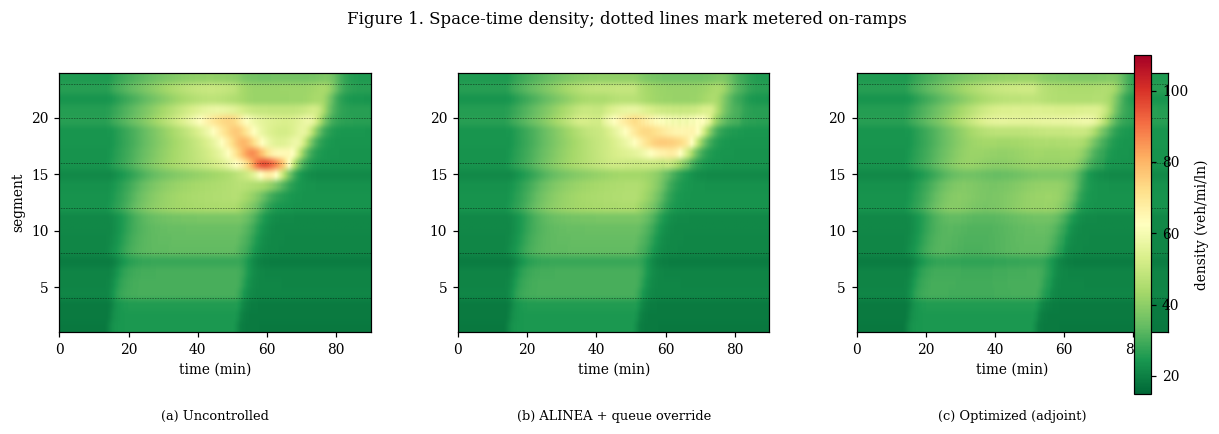

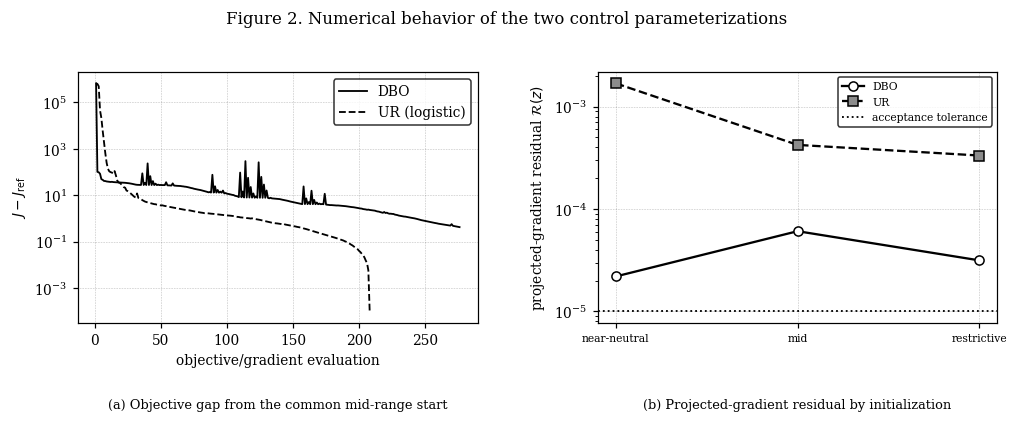

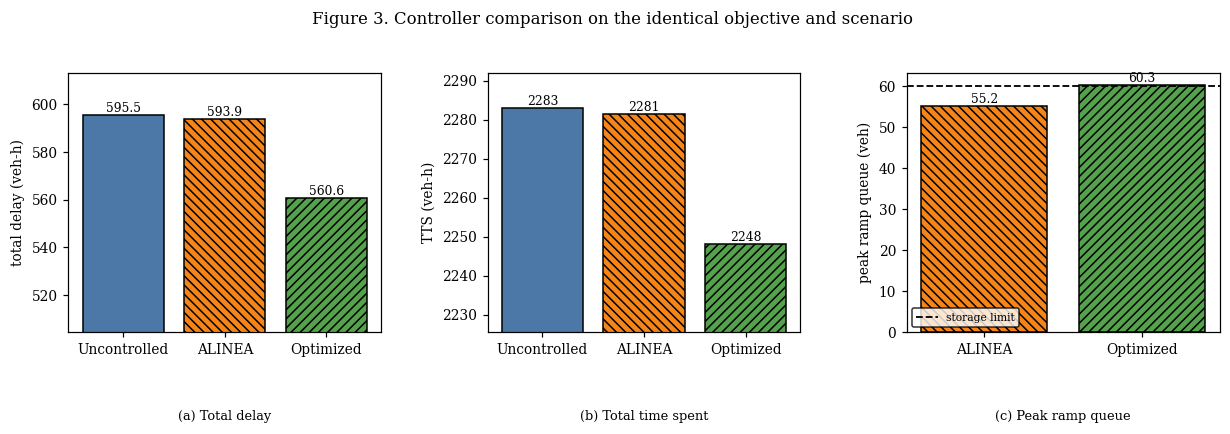

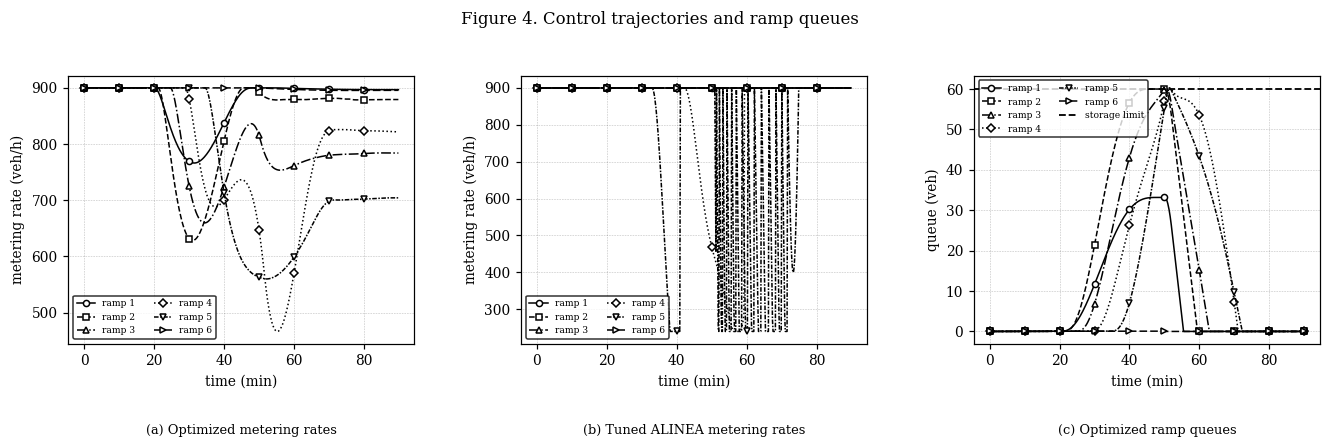

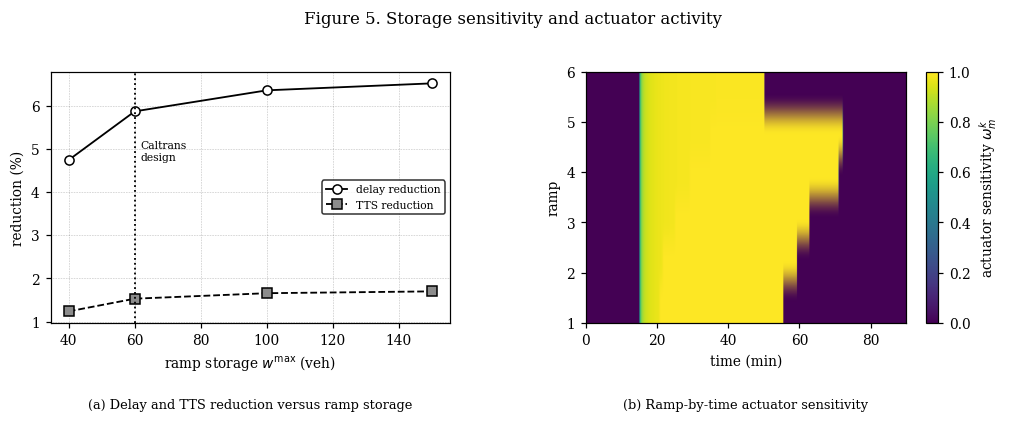

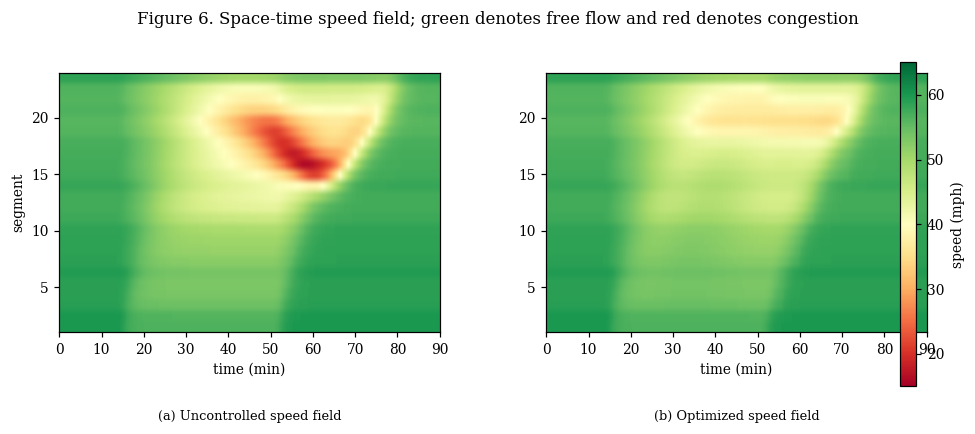


Figures written: fig1 and fig6 (colour fields); fig3 (colour bars); fig5 right panel (colour actuator map); fig2 and fig4 retain line-style/marker differentiation.


In [ ]:
# -*- coding: utf-8 -*-
r"""
===============================================================================
 OPTIMAL RAMP METERING ON A DIRECTIONAL FREEWAY CORRIDOR
 Case study: I-210 West, Pasadena, California  (12 mi, 6 metered on-ramps)
===============================================================================
 SELF-CONTAINED.  Paste this whole file into ONE Google Colab cell and run.
 It executes automatically and prints every result, then draws all figures.

 Needs only numpy / scipy / matplotlib (all pre-installed in Colab).

 Runtime:  FULL  ~10-14 min   (set QUICK=False, default -> paper numbers)
           QUICK ~2-3  min    (set QUICK=True, same code paths, coarser)

 Implements the corrected model:
   power-mean smooth minimum defined at zero with explicit boundary
   derivative; discrete adjoint incl. the control-smoothness term; penalty
   continuation; scale-invariant projected-gradient (KKT) test; verification
   V1-V6; ALINEA benchmark with queue override, jointly tuned.
===============================================================================
"""
import numpy as np, time, json
from scipy.optimize import minimize
import matplotlib
import matplotlib.pyplot as plt

QUICK = False          # <-- set True for a fast smoke run

np.set_printoptions(suppress=True, linewidth=140)
RULE = "=" * 78
def head(t):
    print("\n" + RULE); print(t); print(RULE)


# =============================================================================
# 1. PARAMETERS  (US customary units: mi, mph, veh/mi/lane, veh/h, h)
# =============================================================================
def make_params():
    P = {}
    # --- Geometry: I-210 W Pasadena, 12-mile directional subsection ---
    P['N'] = 24; P['dx'] = 0.5; P['lam'] = 4          # 24 x 0.5 mi, 4 GP lanes
    P['M'] = 6
    P['ramp_seg'] = np.array([3, 7, 11, 15, 19, 22])  # on-ramps  (0-indexed)
    P['off_seg']  = np.array([5, 13, 20])             # off-ramps (0-indexed)
    P['beta']     = np.array([0.08, 0.08, 0.08])
    P['T'] = 10.0/3600.0
    P['K'] = 540 if not QUICK else 420                # 90 (or 70) min

    # --- Fundamental diagram (HCM-consistent) ---
    P['vf'] = 65.0; P['rhocr'] = 50.0; P['a'] = 1.9; P['rhoJ'] = 200.0
    # --- METANET dynamics (Papageorgiou et al. 1990, US-unit scaled) ---
    P['tau'] = 20.0/3600.0; P['nu'] = 13.5; P['kappa'] = 21.0
    P['delta'] = 0.0196; P['vflat'] = 5.0
    P['C'] = P['lam']*P['rhocr']*P['vf']*np.exp(-1.0/P['a'])

    # --- Ramp metering: FHWA ATDM Guide (2013) ALINEA defaults ---
    P['rmin'] = 240.0; P['rmax'] = 900.0; P['Qm'] = 2100.0
    # --- Storage: Caltrans RMDM, 7% of peak-hour ramp volume ---
    P['wmax'] = 60.0; P['w0max'] = 300.0

    # --- Smoothing / weights / tolerances ---
    P['gamma'] = 200.0; P['epsS'] = 0.02; P['epsv'] = 1.0
    P['eps_init'] = 0.02; P['eps_KKT'] = 1e-5
    P['eps_feas_r'] = 0.5; P['eps_feas_w'] = 0.5
    P['sigma'] = 5.0; P['lmax'] = 4
    P['epsJ'] = 0.05; P['Dw'] = 5.0; P['Drho'] = 10.0; P['mus_frac'] = 0.02

    # --- AM-peak demand scenario ---
    P['d0_base'], P['d0_peak'] = 4480.0, 5600.0
    P['dm_base'] = np.full(P['M'], 450.0)
    P['dm_peak'] = np.full(P['M'], 900.0)
    P['q_init'] = 4480.0
    P['peak_start'] = 15.0
    P['peak_end']   = 50.0 if not QUICK else 45.0
    P['ramp_min'] = 2.0
    P['maxiter'] = 200 if not QUICK else 60
    return P


def build_bup(P):
    b = np.zeros(P['N'])
    for j, s in enumerate(np.atleast_1d(P['off_seg'])):
        assert s + 1 < P['N'], "off-ramp must not be in the last segment"
        b[s+1] = np.atleast_1d(P['beta'])[j]
    return b


def solve_rho_init(P):
    V = lambda r: P['vf']*np.exp(-(1.0/P['a'])*(r/P['rhocr'])**P['a'])
    f = lambda r: P['lam']*r*V(r) - P['q_init']
    lo, hi = 1e-9, P['rhocr']
    for _ in range(300):
        m = 0.5*(lo+hi)
        if f(m) > 0: hi = m
        else:        lo = m
    return 0.5*(lo+hi)


def demand_profiles(P):
    K, T = P['K'], P['T']; tm = np.arange(K)*T*60.0
    a, b, r = P['peak_start'], P['peak_end'], P['ramp_min']
    def prof(base, peak):
        o = np.full(K, base, float)
        for k in range(K):
            t = tm[k]
            if   a <= t < b:       o[k] = peak
            elif a-r <= t < a:     o[k] = base + (t-(a-r))/r*(peak-base)
            elif b <= t < b+r:     o[k] = base + (b+r-t)/r*(peak-base)
        return o
    d0 = prof(P['d0_base'], P['d0_peak'])
    dm = np.stack([prof(P['dm_base'][m], P['dm_peak'][m]) for m in range(P['M'])], 1)
    re = solve_rho_init(P)
    return d0, dm, np.full(K, re)


# =============================================================================
# 2. SMOOTH OPERATORS  (Eqs. 4-6 of the manuscript)
# =============================================================================
def pmin(x, g):
    x = np.asarray(x, float)
    z = np.any(x <= 0.0, -1)
    xs = np.where(x <= 0.0, 1.0, x)
    L = np.log(xs); s = np.min(L, -1, keepdims=True)
    v = np.exp(s[..., 0] - (1.0/g)*np.log(np.sum(np.exp(-g*(L-s)), -1)))
    return np.where(z, 0.0, v)

def d_pmin(x, g):
    x = np.asarray(x, float); f = pmin(x, g)[..., None]
    nz = (x <= 0.0); nn = np.sum(nz, -1, keepdims=True)
    gi = np.where(nz, 0.0, (f/np.where(nz, 1.0, x))**(g+1.0))
    return np.where(nn == 1, np.where(nz, 1.0, 0.0), gi)

def sat(y, a, b, e):
    sp = lambda t: np.maximum(t, 0.0) + np.log1p(np.exp(-np.abs(t)))
    return a + e*(sp((y-a)/e) - sp((y-b)/e))

def d_sat(y, a, b, e):
    sg = lambda t: 0.5*(1.0 + np.tanh(0.5*t))
    return sg((y-a)/e) - sg((y-b)/e)

hinge   = lambda y: np.maximum(0.0, y)**2
d_hinge = lambda y: 2.0*np.maximum(0.0, y)


# =============================================================================
# 3. PLANT AND ADJOINT
# =============================================================================
unpack = lambda x, N, M: (x[:N], x[N:2*N], x[2*N:2*N+M], x[2*N+M])
pack   = lambda r, v, w, w0: np.concatenate([r, v, w, [w0]])

def step(x, z, d0, dm, rhod, P):
    N, M, T, dx, lam = P['N'], P['M'], P['T'], P['dx'], P['lam']
    rho, v, w, w0 = unpack(x, N, M)
    r = P['rmin'] + (P['rmax']-P['rmin'])*z
    q = lam*rho*v
    sa = (P['rhoJ']-rho)/(P['rhoJ']-P['rhocr']); S = sat(sa, 0.0, 1.0, P['epsS'])
    lim_r = np.stack([r, dm + w/T, P['Qm']*S[P['ramp_seg']]], -1)
    rt = pmin(lim_r, P['gamma'])
    lim_0 = np.array([d0 + w0/T, P['C']*S[0]]); q0 = pmin(lim_0, P['gamma'])
    q_up = np.empty(N); q_up[0] = q0; q_up[1:] = q[:-1]
    b_up = P['b_up']
    R = np.zeros(N); np.add.at(R, P['ramp_seg'], rt)
    rho_n = rho + T/(dx*lam)*((1.0-b_up)*q_up + R - q)
    V = P['vf']*np.exp(-(1.0/P['a'])*(rho/P['rhocr'])**P['a'])
    v_up = np.empty(N); v_up[0] = v[0]; v_up[1:] = v[:-1]
    rdn = np.empty(N); rdn[:-1] = rho[1:]; rdn[-1] = rhod
    den = rho + P['kappa']; Xi = P['delta']*T*R*v/(dx*lam*den)
    vh = (v + T/P['tau']*(V-v) + T/dx*v*(v_up-v)
          - P['nu']*T/(P['tau']*dx)*(rdn-rho)/den - Xi)
    v_n = sat(vh, P['vflat'], P['vf'], P['epsv'])
    c = dict(rho=rho, v=v, q=q, S=S, sa=sa, lim_r=lim_r, rt=rt, lim_0=lim_0,
             q0=q0, b_up=b_up, R=R, V=V, v_up=v_up, rdn=rdn, den=den, vh=vh)
    return pack(rho_n, v_n, w + T*(dm-rt), w0 + T*(d0-q0)), c


def step_vjp(go, c, P):
    N, M, T, dx, lam = P['N'], P['M'], P['T'], P['dx'], P['lam']
    grn, gvn, gwn, gw0n = unpack(go, N, M)
    rho, v = c['rho'], c['v']
    grho = np.zeros(N); gv = np.zeros(N); gw = np.zeros(M); gw0 = 0.0
    gz = np.zeros(M)
    gw += gwn;  g_rt = -T*gwn
    gw0 += gw0n; g_q0 = -T*gw0n
    g_vh = gvn*d_sat(c['vh'], P['vflat'], P['vf'], P['epsv'])
    gv += g_vh*(1.0 - T/P['tau'])
    g_V = g_vh*(T/P['tau'])
    gv += g_vh*(T/dx)*(c['v_up']-v) - g_vh*(T/dx)*v
    g_vup = g_vh*(T/dx)*v
    co = -P['nu']*T/(P['tau']*dx); den = c['den']
    g_rdn = g_vh*co/den
    grho += g_vh*co*((-(den)-(c['rdn']-rho))/den**2)
    g_R = -g_vh*P['delta']*T*v/(dx*lam*den)
    gv += -g_vh*P['delta']*T*c['R']/(dx*lam*den)
    grho += g_vh*P['delta']*T*c['R']*v/(dx*lam*den**2)
    gv[0] += g_vup[0]; gv[:-1] += g_vup[1:]
    grho += g_V*c['V']*(-(rho/P['rhocr'])**(P['a']-1.0)/P['rhocr'])
    grho[1:] += g_rdn[:-1]
    grho += grn; fac = T/(dx*lam)
    g_qup = grn*fac*(1.0-c['b_up']); g_R = g_R + grn*fac; g_q = -grn*fac
    g_rt = g_rt + g_R[P['ramp_seg']]; g_q0 += g_qup[0]
    gq = g_q.copy(); gq[:-1] += g_qup[1:]
    grho += gq*lam*v; gv += gq*lam*rho
    w0s = d_pmin(c['lim_0'], P['gamma'])
    gw0 += g_q0*w0s[0]/T; g_S0 = g_q0*w0s[1]*P['C']
    rs = d_pmin(c['lim_r'], P['gamma'])
    gz += g_rt*rs[:, 0]*(P['rmax']-P['rmin'])
    gw += g_rt*rs[:, 1]/T
    g_Sr = g_rt*rs[:, 2]*P['Qm']
    gS = np.zeros(N); gS[0] += g_S0; np.add.at(gS, P['ramp_seg'], g_Sr)
    grho += gS*d_sat(c['sa'], 0.0, 1.0, P['epsS'])*(-1.0/(P['rhoJ']-P['rhocr']))
    return pack(grho, gv, gw, gw0), gz


def simulate(zs, P, dem, x0=None):
    d0s, dms, rds = dem
    x = P['x0'] if x0 is None else x0
    xs = [x]; cs = []
    for k in range(P['K']):
        x, c = step(x, zs[k], d0s[k], dms[k], rds[k], P); xs.append(x); cs.append(c)
    return np.array(xs), cs


def objective(zf, P, dem, kind='DBO', parts=False):
    N, M, K = P['N'], P['M'], P['K']
    th = zf.reshape(K, M)
    z = 1.0/(1.0+np.exp(-th)) if kind == 'UR' else th
    xs, cs = simulate(z, P, dem)
    T, dx, lam = P['T'], P['dx'], P['lam']
    rho = xs[:, :N]; w = xs[:, 2*N:2*N+M]; w0 = xs[:, 2*N+M]; v = xs[:, N:2*N]
    veh = np.sum(rho*dx*lam, 1) + np.sum(w, 1) + w0
    tts = T*np.sum(veh[:K]); zeta = (N*dx)/P['vf']; Phi = zeta*veh[K]
    Pw = np.sum(hinge(w-P['wmax'])) + np.sum(hinge(w0-P['w0max']))
    Pr = np.sum(hinge(rho-P['rhoJ']))
    Ps = np.sum(np.diff(z, axis=0)**2)
    J = tts + Phi + P['muw']*Pw + P['murho']*Pr + P['mus']*Ps
    if parts:
        VMT = np.sum(rho[:K]*lam*dx*v[:K]*T)
        return J, dict(tts=tts, Phi=Phi, Pw=Pw, Prho=Pr, Ps=Ps, xs=xs, z=z,
                       VMT=VMT, ff=VMT/P['vf'], delay=tts-VMT/P['vf'],
                       maxrho=rho.max(), maxw=w.max(), maxw0=w0.max(),
                       minv=v.min())
    return J, (xs, cs, z)


def gradient(zf, P, dem, kind='DBO'):
    N, M, K = P['N'], P['M'], P['K']
    J, (xs, cs, z) = objective(zf, P, dem, kind)
    T, dx, lam = P['T'], P['dx'], P['lam']; zeta = (N*dx)/P['vf']
    gd = np.zeros_like(xs)
    gd[:K, :N] += T*dx*lam; gd[:K, 2*N:2*N+M] += T; gd[:K, 2*N+M] += T
    gd[K, :N] += zeta*dx*lam; gd[K, 2*N:2*N+M] += zeta; gd[K, 2*N+M] += zeta
    gd[:, :N] += P['murho']*d_hinge(xs[:, :N]-P['rhoJ'])
    gd[:, 2*N:2*N+M] += P['muw']*d_hinge(xs[:, 2*N:2*N+M]-P['wmax'])
    gd[:, 2*N+M] += P['muw']*d_hinge(xs[:, 2*N+M]-P['w0max'])
    gz = np.zeros((K, M)); p = gd[K].copy()
    for k in range(K-1, -1, -1):
        gx, gk = step_vjp(p, cs[k], P); gz[k] += gk; p = gx + gd[k]
    dz = np.diff(z, axis=0)
    sm = np.zeros((K, M)); sm[:-1] += -2*dz; sm[1:] += 2*dz
    gz += P['mus']*sm
    if kind == 'UR': gz = gz*(z*(1.0-z))
    return J, gz.ravel()


def kkt(z, P, dem):
    _, g = gradient(z, P, dem, 'DBO')
    gb = g/P['TTSref']
    return float(np.max(np.abs(z - np.clip(z-gb, 0.0, 1.0))))


# =============================================================================
# 4. SETUP
# =============================================================================
def setup(P=None):
    if P is None: P = make_params()
    P['b_up'] = build_bup(P)
    N, M, K = P['N'], P['M'], P['K']
    r0 = solve_rho_init(P)
    V0 = P['vf']*np.exp(-(1.0/P['a'])*(r0/P['rhocr'])**P['a'])
    P['x0'] = pack(np.full(N, r0), np.full(N, V0), np.zeros(M), 0.0)
    P['rho_init'], P['V_init'] = r0, V0
    for k in ('muw', 'murho', 'mus'): P[k] = 0.0
    dem = demand_profiles(P)
    # warm-up under the neutral policy -> x0 consistent with the smoothed model
    Kw = 240; Pw = dict(P); Pw['K'] = Kw
    demw = (np.full(Kw, P['d0_base']), np.tile(P['dm_base'], (Kw, 1)), np.full(Kw, r0))
    xw, _ = simulate(np.ones((Kw, M)), Pw, demw)
    P['x0'] = xw[-1]; P['warm_drift'] = float(np.abs(xw[-1]-xw[-2]).max())
    _, pr = objective(np.ones(K*M), P, dem, 'DBO', parts=True)
    P['TTSref'] = pr['tts']; P['DELAYref'] = pr['delay']
    P['muw']   = P['epsJ']*P['TTSref']/((K+1)*(M+1)*P['Dw']**2)
    P['murho'] = P['epsJ']*P['TTSref']/((K+1)*N*P['Drho']**2)
    P['mus']   = P['mus_frac']*P['TTSref']
    P['mu_w0'] = P['muw']
    return P, dem


def solve_one(z0, P, dem, kind, maxiter=None, hist=False):
    n = P['K']*P['M']; mi = maxiter or P['maxiter']
    H = []
    def fun(u):
        J, g = gradient(u, P, dem, kind)
        if hist: H.append(J)
        return J, g
    if kind == 'DBO': x0, bd = np.clip(z0, 0, 1), [(0.0, 1.0)]*n
    else:             x0, bd = np.log(np.clip(z0, 1e-6, 1-1e-6)/(1-np.clip(z0, 1e-6, 1-1e-6))), None
    t0 = time.time()
    r = minimize(fun, x0, method='L-BFGS-B', jac=True, bounds=bd,
                 options=dict(maxiter=mi, maxfun=3*mi, ftol=1e-14, gtol=1e-12, maxcor=20))
    J, pt = objective(r.x, P, dem, kind, parts=True)
    zs = pt['z'].ravel()
    return dict(kind=kind, J=float(J), tts=float(pt['tts']), delay=float(pt['delay']),
                VMT=float(pt['VMT']), maxrho=float(pt['maxrho']), maxw=float(pt['maxw']),
                maxw0=float(pt['maxw0']), nit=int(r.nit), nfev=int(r.nfev),
                time=time.time()-t0, z=zs, x=r.x.copy(), kkt=kkt(zs, P, dem),
                pt=pt, hist=H, msg=str(r.message))


def feas(m, P):
    return (m['maxrho']-P['rhoJ'] <= P['eps_feas_r'] and
            m['maxw']-P['wmax'] <= P['eps_feas_w'] and
            m['maxw0']-P['w0max'] <= P['eps_feas_w'])


# =============================================================================
# 5. ALINEA BENCHMARK  (queue override, jointly tuned)
# =============================================================================
def alinea(P, dem, KR, fr, wt):
    N, M, K = P['N'], P['M'], P['K']
    d0s, dms, rds = dem
    x = P['x0']; rp = np.full(M, P['rmax']); z = np.zeros((K, M))
    for k in range(K):
        rho = x[:N]; w = x[2*N:2*N+M]
        rn = np.clip(rp + KR*(fr*P['rhocr'] - rho[P['ramp_seg']]), P['rmin'], P['rmax'])
        rn = np.where(w > wt*P['wmax'], P['rmax'], rn)
        z[k] = (rn-P['rmin'])/(P['rmax']-P['rmin'])
        x, _ = step(x, z[k], d0s[k], dms[k], rds[k], P); rp = rn
    return z.ravel()


def alinea_tune(P, dem):
    grid_K = [10., 20., 40., 70.]; grid_f = [0.85, 0.95, 1.0]; grid_w = [0.75, 0.90]
    best = None; n = 0
    for KR in grid_K:
        for fr in grid_f:
            for wt in grid_w:
                z = alinea(P, dem, KR, fr, wt)
                J, pt = objective(z, P, dem, 'DBO', parts=True); n += 1
                if best is None or J < best[0]: best = (J, pt, KR, fr, wt, z)
    return best, n

# =============================================================================
# 6. VERIFICATION V1-V6
# =============================================================================
def verification(P, dem):
    head("TABLE 2.  NUMERICAL VERIFICATION")
    N, M, K = P['N'], P['M'], P['K']; n = K*M
    rng = np.random.default_rng(7); rows = []

    for kind in ('DBO', 'UR'):
        z = rng.uniform(0.3, 0.7, n) if kind == 'DBO' else rng.uniform(-1, 1, n)
        _, g = gradient(z, P, dem, kind)
        e = 1e-6; err = 0.0
        for i in rng.choice(n, 20, replace=False):
            zp = z.copy(); zp[i] += e; zm = z.copy(); zm[i] -= e
            fd = (objective(zp, P, dem, kind)[0]-objective(zm, P, dem, kind)[0])/(2*e)
            err = max(err, abs(fd-g[i]))
        rows.append(("V1  adjoint vs central differences [%s]" % kind,
                     "%.2e" % err, "PASS" if err < 1e-4 else "FAIL"))

    # V1b dedicated zero-availability branch
    Pz = dict(P); Kz = 30; Pz['K'] = Kz
    demz = (np.full(Kz, P['d0_base']), np.zeros((Kz, M)), np.full(Kz, P['rho_init']))
    Pz['x0'] = P['x0'].copy(); Pz['x0'][2*N:2*N+M] = 0.0
    zz = np.full(Kz*M, 0.5); _, gz = gradient(zz, Pz, demz, 'DBO')
    e = 1e-7; eb = 0.0
    for i in rng.choice(Kz*M, 8, replace=False):
        zp = zz.copy(); zp[i] += e
        eb = max(eb, abs((objective(zp, Pz, demz, 'DBO')[0]
                          - objective(zz, Pz, demz, 'DBO')[0])/e - gz[i]))
    rows.append(("V1  zero-availability boundary branch", "%.2e" % eb,
                 "PASS" if (eb < 1e-3 and np.all(np.isfinite(gz))) else "FAIL"))

    # V2 conservation + domain
    zt = np.full((K, M), 0.6); xs, cs = simulate(zt, P, dem)
    d0s, dms, _ = dem; T, dx, lam = P['T'], P['dx'], P['lam']
    Sig = lambda x: np.sum(dx*lam*x[:N])+np.sum(x[2*N:2*N+M])+x[2*N+M]
    res = 0.0
    for k in range(K):
        div = sum(np.atleast_1d(P['beta'])[j]*cs[k]['q'][s]
                  for j, s in enumerate(np.atleast_1d(P['off_seg'])))
        rhs = T*(d0s[k]+dms[k].sum()-div-cs[k]['q'][-1])
        res = max(res, abs(Sig(xs[k+1])-Sig(xs[k])-rhs))
    rows.append(("V2  vehicle conservation residual (veh)", "%.2e" % res,
                 "PASS" if res < 1e-8 else "FAIL"))
    rho = xs[:, :N]; v = xs[:, N:2*N]
    ok = rho.min() > 0 and v.min() > P['vflat'] and v.max() < P['vf']
    rows.append(("V2  domain invariance  rho_min=%.2f, v in [%.1f,%.1f]"
                 % (rho.min(), v.min(), v.max()), "-", "PASS" if ok else "FAIL"))

    c1, c2 = P['dx']/P['vf'], P['tau']
    J0, g0 = gradient(np.full(n, 0.5), P, dem, 'DBO')
    rows.append(("V3  T=%.1fs <= min(dx/vf,tau)=%.1fs; J,gradJ finite"
                 % (P['T']*3600, min(c1, c2)*3600), "-",
                 "PASS" if (P['T'] <= min(c1, c2) and np.isfinite(J0)) else "FAIL"))
    rows.append(("V4  smooth-min worst-case error (L=3, gamma=%.0f)" % P['gamma'],
                 "%.3f%%" % (100*(1-3**(-1.0/P['gamma']))), "reported"))

    print("%-58s %12s %8s" % ("Check", "Value", "Status"))
    print("-"*78)
    for a, b, c in rows: print("%-58s %12s %8s" % (a, b, c))
    return rows


# =============================================================================
# 7. MAIN STUDY
# =============================================================================
def main():
    t00 = time.time()
    head("OPTIMAL RAMP METERING -- I-210 W, PASADENA, CALIFORNIA")
    P, dem = setup()
    N, M, K = P['N'], P['M'], P['K']; n = K*M

    # ---------------- Table 1: configuration ----------------
    head("TABLE 1.  NETWORK, PARAMETERS AND DATA SOURCES")
    print("%-34s %-16s %s" % ("Quantity", "Value", "Source / note"))
    print("-"*78)
    T1 = [("Corridor length", "%.1f mi" % (N*P['dx']), "I-210 W subsection"),
          ("Segments x length", "%d x %.1f mi" % (N, P['dx']), "METANET discretization"),
          ("Lanes (GP)", "%d" % P['lam'], "I-210 W mainline"),
          ("Metered on-ramps", "%d" % M, "segments %s" % (P['ramp_seg']+1)),
          ("Off-ramps", "%d (beta=%.2f)" % (len(np.atleast_1d(P['off_seg'])), P['beta'][0]),
           "segments %s" % (np.atleast_1d(P['off_seg'])+1)),
          ("Time step / horizon", "%.0f s / %.0f min" % (P['T']*3600, K*P['T']*60), "CFL-compliant"),
          ("Free-flow speed", "%.0f mph" % P['vf'], "HCM / posted"),
          ("Critical density", "%.0f veh/mi/ln" % P['rhocr'], "HCM-consistent"),
          ("Jam density", "%.0f veh/mi/ln" % P['rhoJ'], "~26 ft/veh"),
          ("Capacity", "%.0f veh/h (%.0f /ln)" % (P['C'], P['C']/P['lam']), "HCM 1800-2000 /ln"),
          ("FD exponent  a", "%.2f" % P['a'], "shape of V(rho)"),
          ("Relaxation time  tau", "%.0f s" % (P['tau']*3600), "METANET, Papageorgiou et al. 1990"),
          ("Anticipation  nu / kappa", "%.1f mi2/h / %.0f" % (P['nu'], P['kappa']),
           "METANET, US-unit scaled"),
          ("Merging coefficient  delta", "%.4f" % P['delta'],
           "METANET; see mechanism check, Table 7"),
          ("Metering rate bounds", "%.0f - %.0f veh/h" % (P['rmin'], P['rmax']),
           "FHWA ATDM Guide (2013)"),
          ("Ramp storage", "%.0f veh" % P['wmax'], "Caltrans RMDM, 7% rule"),
          ("Mainline demand base/peak", "%.0f / %.0f veh/h" % (P['d0_base'], P['d0_peak']), "AM peak"),
          ("Ramp demand base/peak", "%.0f / %.0f veh/h" % (P['dm_base'][0], P['dm_peak'][0]), "AM peak"),
          ("Decision variables", "%d" % n, "n = K x M"),
          ("Warm-up residual drift", "%.2e" % P['warm_drift'], "consistent x0")]
    for a, b, c in T1: print("%-34s %-16s %s" % (a, b, c))

    verification(P, dem)

    # ---------------- penalty continuation ----------------
    head("TABLE 3.  PENALTY CONTINUATION (Section 2.6)")
    print("%-6s %-10s %10s %10s %10s %9s" % ("level", "mu_w x", "J", "TTS", "max queue", "feasible"))
    print("-"*78)
    z0 = np.full(n, 1-P['eps_init']); cont = []
    for l in range(P['lmax']):
        r = solve_one(z0, P, dem, 'DBO')
        ok = feas(r, P); cont.append((l, P['muw']/P['mu_w0'], r['J'], r['tts'], r['maxw'], ok))
        print("%-6d %-10.0f %10.2f %10.2f %10.2f %9s"
              % (l, P['muw']/P['mu_w0'], r['J'], r['tts'], r['maxw'], ok))
        if ok: break
        P['muw'] *= P['sigma']; z0 = r['x']
    OPT = r
    print("-> common final weights: mu_w = %.4e (x%.0f), mu_rho = %.4e"
          % (P['muw'], P['muw']/P['mu_w0'], P['murho']))

    print("\nPRIMARY SOLUTION DIAGNOSTICS")
    print("Projected-gradient residual : %.8e" % OPT['kkt'])
    print("Iterations                  : %d" % OPT['nit'])
    print("Stopping message            : %s" % OPT['msg'])
    print("Peak ramp queue             : %.8f" % OPT['maxw'])
    print("Ramp-storage excess         : %.8f" % max(0.0, OPT['maxw'] - P['wmax']))
    print("Peak density                : %.8f" % OPT['maxrho'])
    print("Density-limit excess        : %.8f" % max(0.0, OPT['maxrho'] - P['rhoJ']))

    # ---------------- baselines ----------------
    head("TABLE 4.  CONTROLLER COMPARISON (identical objective and scenario)")
    Jn, PN = objective(np.ones(n), P, dem, 'DBO', parts=True)
    (Ja, PA, KRb, frb, wtb, za), ntry = alinea_tune(P, dem)
    PO = OPT['pt']
    rows = [("Uncontrolled", None, PN), ("ALINEA + queue override", Ja, PA),
            ("Optimal (adjoint)", OPT['J'], PO)]
    print("%-24s %9s %9s %9s %8s %8s %7s" %
          ("Controller", "J", "TTS", "Delay", "maxQueue", "maxRho", "feas"))
    print("-"*78)
    for nm, Jv, pt in rows:
        fz = dict(maxrho=pt['maxrho'], maxw=pt['maxw'], maxw0=pt['maxw0'])
        print("%-24s %9s %9.2f %9.2f %8.1f %8.1f %7s"
              % (nm, "--" if Jv is None else "%.1f" % Jv, pt['tts'], pt['delay'],
                 pt['maxw'], pt['maxrho'], "--" if Jv is None else feas(fz, P)))
    dR = lambda a, b: 100*(a-b)/a
    print("-"*78)
    print("ALINEA tuning: %d joint combinations; best K_R=%.0f, rho_hat=%.2f*rho_cr, "
          "override at %.0f%% of storage" % (ntry, KRb, frb, 100*wtb))
    print("DELAY reduction vs uncontrolled :  Optimal %5.2f%%   ALINEA %5.2f%%"
          % (dR(PN['delay'], PO['delay']), dR(PN['delay'], PA['delay'])))
    print("TTS   reduction vs uncontrolled :  Optimal %5.2f%%   ALINEA %5.2f%%"
          % (dR(PN['tts'], PO['tts']), dR(PN['tts'], PA['tts'])))
    print("Optimal vs ALINEA               :  %5.2f%% lower delay"
          % dR(PA['delay'], PO['delay']))
    print("VMT (veh-mi)                    :  unc %.0f | ALINEA %.0f | opt %.0f  "
          "(equal throughput => pure delay saving)" % (PN['VMT'], PA['VMT'], PO['VMT']))
    print("Peak density (veh/mi/ln)        :  %.0f -> %.0f" % (PN['maxrho'], PO['maxrho']))

    # ---------------- DBO vs UR ----------------
    head("TABLE 5.  PARAMETERIZATION COMPARISON (DBO vs UR), fixed weights")
    S = {'near-neutral': np.full(n, 1-P['eps_init']),
         'mid': np.full(n, 0.5), 'restrictive': np.full(n, 0.30)}
    CMP = {'DBO': [], 'UR': []}
    print("%-6s %-14s %10s %9s %10s %6s %7s %6s" %
          ("method", "start", "J", "TTS", "KKT res.", "iters", "time(s)", "conv"))
    print("-"*78)
    for kind in ('DBO', 'UR'):
        for nm, z0 in S.items():
            rr = solve_one(z0, P, dem, kind); rr['start'] = nm
            rr['conv'] = rr['kkt'] <= P['eps_KKT']
            CMP[kind].append(rr)
            print("%-6s %-14s %10.3f %9.2f %10.2e %6d %7.1f %6s"
                  % (kind, nm, rr['J'], rr['tts'], rr['kkt'], rr['nit'], rr['time'], rr['conv']))
    bD = min(CMP['DBO'], key=lambda r: r['J']); bU = min(CMP['UR'], key=lambda r: r['J'])
    print("-"*78)
    print("best J : DBO %.4f | UR %.4f  (difference %.2e)" % (bD['J'], bU['J'], abs(bD['J']-bU['J'])))
    print("KKT    : DBO %.2e | UR %.2e  ; converged runs: DBO %d/%d, UR %d/%d"
          % (bD['kkt'], bU['kkt'], sum(r['conv'] for r in CMP['DBO']), len(S),
             sum(r['conv'] for r in CMP['UR']), len(S)))

    # ---------------- convergence histories ----------------
    hD = solve_one(S['mid'], P, dem, 'DBO', hist=True)['hist']
    hU = solve_one(S['mid'], P, dem, 'UR',  hist=True)['hist']

    # ---------------- storage sensitivity ----------------
    head("TABLE 6.  RAMP-STORAGE SENSITIVITY")
    grid = [40., 60., 100., 150.] if not QUICK else [40., 60., 100.]
    ST = []
    print("%-12s %-12s %10s %10s %9s %9s" %
          ("w_max (veh)", "total (veh)", "TTS", "Delay", "TTSgain%", "Delaygain%"))
    print("-"*78)
    for wm in grid:
        Pw = dict(P); Pw['wmax'] = wm
        Jn2, pn2 = objective(np.ones(n), Pw, dem, 'DBO', parts=True)
        rw = solve_one(np.full(n, 1-P['eps_init']), Pw, dem, 'DBO')
        g1 = 100*(pn2['tts']-rw['tts'])/pn2['tts']
        g2 = 100*(pn2['delay']-rw['delay'])/pn2['delay']
        ST.append((wm, M*wm, rw['tts'], rw['delay'], g1, g2))
        print("%-12.0f %-12.0f %10.2f %10.2f %9.2f %9.2f" % ST[-1])
        print("   diagnostics: J=%.8f, KKT=%.8e, iterations=%d, stop=%s"
                % (rw['J'], rw['kkt'], rw['nit'], rw['msg']))
        print("\nStorage-sensitivity settings:")
        print("Initialization for every storage case : near-neutral z = %.2f" % (1-P['eps_init']))
        print("Maximum iterations                   : %d" % P['maxiter'])
        print("Final queue-penalty weight            : %.8e" % P['muw'])
        print("Fixed density-penalty weight          : %.8e" % P['murho'])
    # ---------------- diagnostics ----------------
    head("TABLE 7.  DIAGNOSTICS (V5-V6)")
    xs, cs = simulate(OPT['z'].reshape(K, M), P, dem)
    om = np.array([d_pmin(c['lim_r'], P['gamma'])[:, 0] for c in cs])
    alpha = float(np.mean(om > 0.5))
    print("V5  actuator activity ratio alpha        : %.3f" % alpha)
    print("V5  omega range                          : [%.2e, %.12f]" % (om.min(), om.max()))
    print("    (omega<1 exactly; the gap is O(1e-39), below double precision)")
    print("V5  ablation dJ = J_neutral - J_opt      : %.3f  (delay %.2f -> %.2f)"
          % (Jn-OPT['J'], PN['delay'], PO['delay']))
    # --- mechanism check: switch the merging (capacity-drop) term off ---
    # If the benefit survives delta = 0, metering is acting by redistributing
    # ramp arrivals against the mainline capacity constraint, not by
    # preventing a merge capacity drop.
    P0 = dict(P); P0['delta'] = 0.0
    _, PN0 = objective(np.ones(n), P0, dem, 'DBO', parts=True)
    r0 = solve_one(np.full(n, 1-P['eps_init']), P0, dem, 'DBO')
    d0red = 100*(PN0['delay'] - r0['delay'])/PN0['delay']
    dbase = dR(PN['delay'], PO['delay'])
    print("V5  mechanism check, delta = 0 (merging term off):")
    print("      delay reduction %.2f%%  vs %.2f%% at delta = %.4f  (difference %.2f pp)"
          % (d0red, dbase, P['delta'], abs(d0red - dbase)))
    print("      -> the benefit does not rely on the merge capacity-drop term;")
    print("         metering acts by redistributing ramp arrivals against the")
    print("         mainline capacity constraint (cf. storage sensitivity, Table 6).")
    zz = [r['z'] for r in CMP['DBO']]; JJ = [r['J'] for r in CMP['DBO']]
    i0, i1 = int(np.argmin(JJ)), int(np.argsort(JJ)[1])
    seg = [objective((1-t)*zz[i0]+t*zz[i1], P, dem, 'DBO')[0] for t in np.linspace(0, 1, 5)]
    print("V6  identifiability: max|dz|=%.4f, J spread along segment = %.2e"
          % (np.abs(zz[i0]-zz[i1]).max(), max(seg)-min(seg)))

    # ---------------- copy-paste summary ----------------
    head("SUMMARY FOR THE MANUSCRIPT")
    print("""On a %.0f-mile directional subsection of I-210 West with %d metered on-ramps
and a %.0f-minute AM-peak horizon (%d decision variables), the optimal policy
reduces total delay from %.2f to %.2f veh-h, a reduction of %.2f%%, while
respecting the %.0f-veh ramp storage limit (peak queue %.2f veh).  A jointly
tuned ALINEA controller with queue override achieves %.2f%%; the optimal policy
is %.2f%% better in delay.  Vehicle-miles travelled are identical across
policies (%.0f veh-mi), so the saving is delay, not throughput accounting.
Peak density falls from %.0f to %.0f veh/mi/lane.  The benefit is bounded by
ramp storage: it rises from %.2f%% at %.0f veh/ramp to %.2f%% at %.0f veh/ramp
and then saturates, which is consistent with metering acting by redistributing
ramp arrivals against the mainline capacity constraint rather than by
suppressing a merge capacity drop (Table 7, mechanism check).  Direct bounded optimization attains a projected-gradient
residual of %.1e against %.1e for the logistic reparameterization, which does
not meet the %.0e acceptance tolerance within %d iterations.""" % (
        N*P['dx'], M, K*P['T']*60, n, PN['delay'], PO['delay'],
        dR(PN['delay'], PO['delay']), P['wmax'], PO['maxw'],
        dR(PN['delay'], PA['delay']), dR(PA['delay'], PO['delay']),
        PN['VMT'], PN['maxrho'], PO['maxrho'],
        ST[0][5], ST[0][0], ST[-1][5], ST[-1][0],
        bD['kkt'], bU['kkt'], P['eps_KKT'], P['maxiter']))

    print("\nTotal wall time: %.1f s" % (time.time()-t00))
    figures(P, dem, PN, PA, PO, OPT, CMP, hD, hU, ST, om)
    return dict(P=P, dem=dem, PN=PN, PA=PA, PO=PO, OPT=OPT, CMP=CMP, ST=ST)


# =============================================================================
# 8. FIGURES
# =============================================================================
def figures(P, dem, PN, PA, PO, OPT, CMP, hD, hU, ST, om):
    """
    Plotting only. This function does not alter the traffic model, objective,
    optimization, verification, or any numerical result produced above.

    Requested presentation updates:
      * Figure 3 is shown in color.
      * The ramp-versus-time actuator-activity panel in Figure 5 is shown in color.
      * All three panels in Figure 4 include legends.
      * Every subplot in Figures 1-6 has a caption below the subplot.
    """
    N, M, K = P['N'], P['M'], P['K']
    t = np.arange(K)*P['T']*60
    tK = np.arange(K+1)*P['T']*60

    plt.rcParams.update({
        'font.size': 9,
        'font.family': 'serif',
        'figure.dpi': 110
    })

    STY = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2)), (0, (1, 1))]
    MRK = ['o', 's', '^', 'D', 'v', '>', '<']
    GRID = dict(alpha=.4, color='k', lw=.4, ls=':')
    LEG = dict(facecolor='white', edgecolor='k')
    me = max(1, K//9)                                   # marker spacing

    # Distinct colors used only where color was requested.
    BAR_COLORS = ['#4C78A8', '#F58518', '#54A24B']

    def panel_caption(a, text, y=-0.30):
        """Place a panel caption beneath an individual subplot."""
        a.text(0.5, y, text, transform=a.transAxes,
               ha='center', va='top', fontsize=8.5)

    # ---------- Fig 1 : density fields (colour retained) ----------
    f, ax = plt.subplots(1, 3, figsize=(12, 4.0))
    for a, pt in [(ax[0], PN), (ax[1], PA), (ax[2], PO)]:
        im = a.imshow(pt['xs'][:, :N].T, aspect='auto', origin='lower',
                      cmap='RdYlGn_r',
                      extent=[0, tK[-1], 1, N], vmin=15, vmax=110)
        a.set_xlabel('time (min)')
        for rs in P['ramp_seg']:
            a.axhline(rs+1, color='k', lw=.4, ls=':')

    ax[0].set_ylabel('segment')
    panel_caption(ax[0], '(a) Uncontrolled')
    panel_caption(ax[1], '(b) ALINEA + queue override')
    panel_caption(ax[2], '(c) Optimized (adjoint)')

    f.colorbar(im, ax=ax, label='density (veh/mi/ln)', fraction=.02)
    f.suptitle('Figure 1. Space-time density; dotted lines mark metered on-ramps',
               y=0.98)
    f.subplots_adjust(left=0.07, right=0.91, bottom=0.25, top=0.84, wspace=0.28)
    plt.savefig('fig1_density.png', bbox_inches='tight')
    plt.show()

    # ---------- Fig 2 : parameterization comparison ----------
    f, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    Js = min(min(hD), min(hU)) - 1e-4

    ax[0].semilogy(np.arange(1, len(hD)+1), np.array(hD)-Js,
                   color='k', ls='-', lw=1.2, label='DBO')
    ax[0].semilogy(np.arange(1, len(hU)+1), np.array(hU)-Js,
                   color='k', ls='--', lw=1.2, label='UR (logistic)')
    ax[0].set_xlabel('objective/gradient evaluation')
    ax[0].set_ylabel(r'$J-J_{\rm ref}$')
    ax[0].legend(**LEG)
    ax[0].grid(**GRID)
    panel_caption(ax[0], '(a) Objective gap from the common mid-range start')

    kd = [r['kkt'] for r in CMP['DBO']]
    ku = [r['kkt'] for r in CMP['UR']]
    xp = np.arange(len(kd))

    ax[1].semilogy(xp, kd, color='k', ls='-', marker='o',
                   mfc='white', ms=6, label='DBO')
    ax[1].semilogy(xp, ku, color='k', ls='--', marker='s',
                   mfc='0.55', ms=6, label='UR')
    ax[1].axhline(P['eps_KKT'], ls=':', c='k', lw=1.2,
                  label=r'acceptance tolerance')
    ax[1].set_xticks(xp)
    ax[1].set_xticklabels([r['start'] for r in CMP['DBO']], fontsize=7)
    ax[1].set_ylabel(r'projected-gradient residual $\mathcal{R}(z)$')
    ax[1].legend(fontsize=7, **LEG)
    ax[1].grid(**GRID)
    panel_caption(ax[1], '(b) Projected-gradient residual by initialization')

    f.suptitle('Figure 2. Numerical behavior of the two control parameterizations',
               y=0.98)
    f.subplots_adjust(left=0.09, right=0.97, bottom=0.27, top=0.84, wspace=0.30)
    plt.savefig('fig2_convergence.png', bbox_inches='tight')
    plt.show()

    # ---------- Fig 3 : controller comparison (COLOR) ----------
    f, ax = plt.subplots(1, 3, figsize=(11.5, 4.0))
    nm = ['Uncontrolled', 'ALINEA', 'Optimized']
    HA = ['', '\\\\\\\\', '////']

    def bars(a, names, vals, colors, hatches, fmt):
        for i, (v, c, h) in enumerate(zip(vals, colors, hatches)):
            a.bar(names[i], v, facecolor=c, edgecolor='k',
                  hatch=h, lw=1.0)
            a.text(i, v, fmt % v, ha='center', va='bottom', fontsize=8)

    dl = [PN['delay'], PA['delay'], PO['delay']]
    bars(ax[0], nm, dl, BAR_COLORS, HA, '%.1f')
    ax[0].set_ylabel('total delay (veh-h)')
    ax[0].set_ylim(min(dl)*.9, max(dl)*1.03)
    panel_caption(ax[0], '(a) Total delay')

    tt = [PN['tts'], PA['tts'], PO['tts']]
    bars(ax[1], nm, tt, BAR_COLORS, HA, '%.0f')
    ax[1].set_ylabel('TTS (veh-h)')
    ax[1].set_ylim(min(tt)*.99, max(tt)*1.004)
    panel_caption(ax[1], '(b) Total time spent')

    qn = ['ALINEA', 'Optimized']
    qv = [PA['maxw'], PO['maxw']]
    qcolors = [BAR_COLORS[1], BAR_COLORS[2]]
    qhatches = ['\\\\\\\\', '////']
    bars(ax[2], qn, qv, qcolors, qhatches, '%.1f')
    ax[2].axhline(P['wmax'], ls='--', c='k', lw=1.2,
                  label='storage limit')
    ax[2].set_ylabel('peak ramp queue (veh)')
    ax[2].legend(fontsize=7, **LEG)
    panel_caption(ax[2], '(c) Peak ramp queue')

    f.suptitle('Figure 3. Controller comparison on the identical objective and scenario',
               y=0.98)
    f.subplots_adjust(left=0.07, right=0.98, bottom=0.25, top=0.84, wspace=0.34)
    plt.savefig('fig3_baselines.png', bbox_inches='tight')
    plt.show()

    # ---------- Fig 4 : control trajectories and queues ----------
    ro = P['rmin'] + (P['rmax']-P['rmin'])*PO['z']
    ra = P['rmin'] + (P['rmax']-P['rmin'])*PA['z']

    f, ax = plt.subplots(1, 3, figsize=(12.5, 4.2))

    # (a) Optimized metering rates
    for m in range(M):
        ax[0].plot(t, ro[:, m], color='k',
                   ls=STY[m % len(STY)], lw=1.0,
                   marker=MRK[m % len(MRK)], markevery=me,
                   ms=4, mfc='white',
                   label='ramp %d' % (m+1))
    ax[0].set_xlabel('time (min)')
    ax[0].set_ylabel('metering rate (veh/h)')
    ax[0].legend(fontsize=6, ncol=2, **LEG)
    ax[0].grid(**GRID)
    panel_caption(ax[0], '(a) Optimized metering rates')

    # (b) ALINEA metering rates -- legend added for every ramp
    for m in range(M):
        ax[1].plot(t, ra[:, m], color='k',
                   ls=STY[m % len(STY)], lw=1.0,
                   marker=MRK[m % len(MRK)], markevery=me,
                   ms=4, mfc='white',
                   label='ramp %d' % (m+1))
    ax[1].set_xlabel('time (min)')
    ax[1].set_ylabel('metering rate (veh/h)')
    ax[1].legend(fontsize=6, ncol=2, **LEG)
    ax[1].grid(**GRID)
    panel_caption(ax[1], '(b) Tuned ALINEA metering rates')

    # (c) Optimized ramp queues
    for m in range(M):
        ax[2].plot(tK, PO['xs'][:, 2*N+m], color='k',
                   ls=STY[m % len(STY)], lw=1.0,
                   marker=MRK[m % len(MRK)], markevery=me,
                   ms=4, mfc='white',
                   label='ramp %d' % (m+1))
    ax[2].axhline(P['wmax'], ls='--', c='k', lw=1.2,
                  label='storage limit')
    ax[2].set_xlabel('time (min)')
    ax[2].set_ylabel('queue (veh)')
    ax[2].legend(fontsize=6, ncol=2, **LEG)
    ax[2].grid(**GRID)
    panel_caption(ax[2], '(c) Optimized ramp queues')

    f.suptitle('Figure 4. Control trajectories and ramp queues', y=0.98)
    f.subplots_adjust(left=0.07, right=0.98, bottom=0.26, top=0.84, wspace=0.31)
    plt.savefig('fig4_control.png', bbox_inches='tight')
    plt.show()

    # ---------- Fig 5 : storage sensitivity + actuator activity ----------
    S = np.array(ST)
    f, ax = plt.subplots(1, 2, figsize=(10.0, 4.0))

    # (a) Storage-sensitivity curves
    ax[0].plot(S[:, 0], S[:, 5], color='k', ls='-',
               marker='o', mfc='white', ms=6, lw=1.2,
               label='delay reduction')
    ax[0].plot(S[:, 0], S[:, 4], color='k', ls='--',
               marker='s', mfc='0.55', ms=6, lw=1.2,
               label='TTS reduction')
    ax[0].axvline(P['wmax'], ls=':', c='k', lw=1.2)
    ax[0].text(P['wmax']*1.03, S[:, 5].min(),
               'Caltrans\ndesign', fontsize=7, color='k')
    ax[0].set_xlabel(r'ramp storage $w^{\max}$ (veh)')
    ax[0].set_ylabel('reduction (%)')
    ax[0].legend(fontsize=7, **LEG)
    ax[0].grid(**GRID)
    panel_caption(ax[0], '(a) Delay and TTS reduction versus ramp storage')

    # (b) Ramp-versus-time actuator activity -- COLOR plot
    im = ax[1].imshow(om.T, aspect='auto', origin='lower',
                      cmap='viridis',
                      extent=[0, t[-1], 1, M], vmin=0, vmax=1)
    ax[1].set_xlabel('time (min)')
    ax[1].set_ylabel('ramp')
    cbar = f.colorbar(im, ax=ax[1])
    cbar.set_label(r'actuator sensitivity $\omega_m^k$')
    panel_caption(ax[1], '(b) Ramp-by-time actuator sensitivity')

    f.suptitle('Figure 5. Storage sensitivity and actuator activity', y=0.98)
    f.subplots_adjust(left=0.08, right=0.93, bottom=0.27, top=0.84, wspace=0.34)
    plt.savefig('fig5_storage_activity.png', bbox_inches='tight')
    plt.show()

    # ---------- Fig 6 : speed fields (colour retained) ----------
    f, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))

    for a, pt in [(ax[0], PN), (ax[1], PO)]:
        im = a.imshow(pt['xs'][:, N:2*N].T, aspect='auto', origin='lower',
                      cmap='RdYlGn',
                      extent=[0, tK[-1], 1, N],
                      vmin=15, vmax=P['vf'])
        a.set_xlabel('time (min)')

    ax[0].set_ylabel('segment')
    panel_caption(ax[0], '(a) Uncontrolled speed field')
    panel_caption(ax[1], '(b) Optimized speed field')

    f.colorbar(im, ax=ax, label='speed (mph)', fraction=.02)
    f.suptitle('Figure 6. Space-time speed field; green denotes free flow and red denotes congestion',
               y=0.98)
    f.subplots_adjust(left=0.08, right=0.91, bottom=0.25, top=0.84, wspace=0.28)
    plt.savefig('fig6_speed.png', bbox_inches='tight')
    plt.show()

    print("\nFigures written: "
          "fig1 and fig6 (colour fields); "
          "fig3 (colour bars); "
          "fig5 right panel (colour actuator map); "
          "fig2 and fig4 retain line-style/marker differentiation.")


# =============================================================================
RESULTS = main()      # <-- runs automatically when the cell is executed


In [ ]:
P = RESULTS['P']
dem = RESULTS['dem']

best_delay = None
n_feasible = 0

for KR in [10., 20., 40., 70.]:
    for fr in [0.85, 0.95, 1.0]:
        for wt in [0.75, 0.90]:

            z = alinea(P, dem, KR, fr, wt)
            J, pt = objective(z, P, dem, 'DBO', parts=True)

            ok = feas(dict(maxrho=pt['maxrho'],
                           maxw=pt['maxw'],
                           maxw0=pt['maxw0']), P)

            if ok:
                n_feasible += 1

                if best_delay is None or pt['delay'] < best_delay[0]:
                    best_delay = (
                        pt['delay'], J, KR, fr, wt,
                        pt['maxw'], pt['maxrho']
                    )

print("Feasible configurations =", n_feasible)
print("Best feasible-delay result:")
print("Delay =", best_delay[0])
print("J =", best_delay[1])
print("K_R =", best_delay[2])
print("rho_hat/rho_cr =", best_delay[3])
print("override fraction =", best_delay[4])
print("peak queue =", best_delay[5])
print("peak density =", best_delay[6])

Feasible configurations = 24
Best feasible-delay result:
Delay = 593.8971132122542
J = 3323.6913690292354
K_R = 10.0
rho_hat/rho_cr = 1.0
override fraction = 0.9
peak queue = 55.210120697797144
peak density = 75.71865667756737
